# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Rayyan Muhtar Ali | 5054251051 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, roc_auc_score)

import warnings
warnings.filterwarnings('ignore')

In [3]:
# load data
df = pd.read_csv('mushrooms.csv')
print(df.shape)
df.head()

(8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [5]:
# cek missing value, di dataset ini missing value direpresentasikan sebagai '?'
print('Missing (NaN):', df.isnull().sum().sum())
print()
# cek kolom yang punya nilai '?'
for col in df.columns:
    if (df[col] == '?').any():
        print(f"Kolom '{col}' punya {(df[col] == '?').sum()} nilai '?'")

Missing (NaN): 0

Kolom 'stalk-root' punya 2480 nilai '?'


In [6]:
# cek jumlah unique value tiap kolom
df.nunique()

class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64

class
e    4208
p    3916
Name: count, dtype: int64



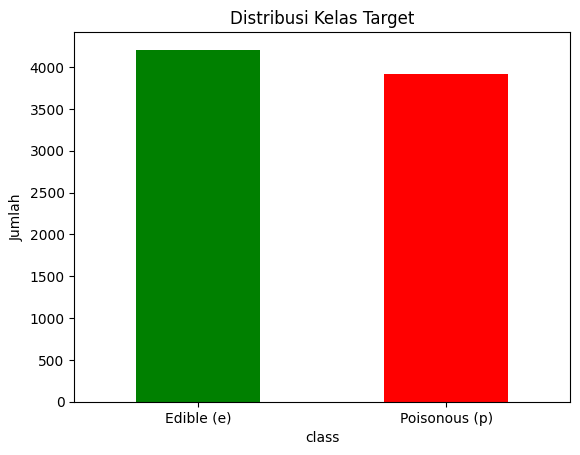

In [7]:
# distribusi kelas
print(df['class'].value_counts())
print()
df['class'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribusi Kelas Target')
plt.ylabel('Jumlah')
plt.xticks(ticks=[0,1], labels=['Edible (e)', 'Poisonous (p)'], rotation=0)
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

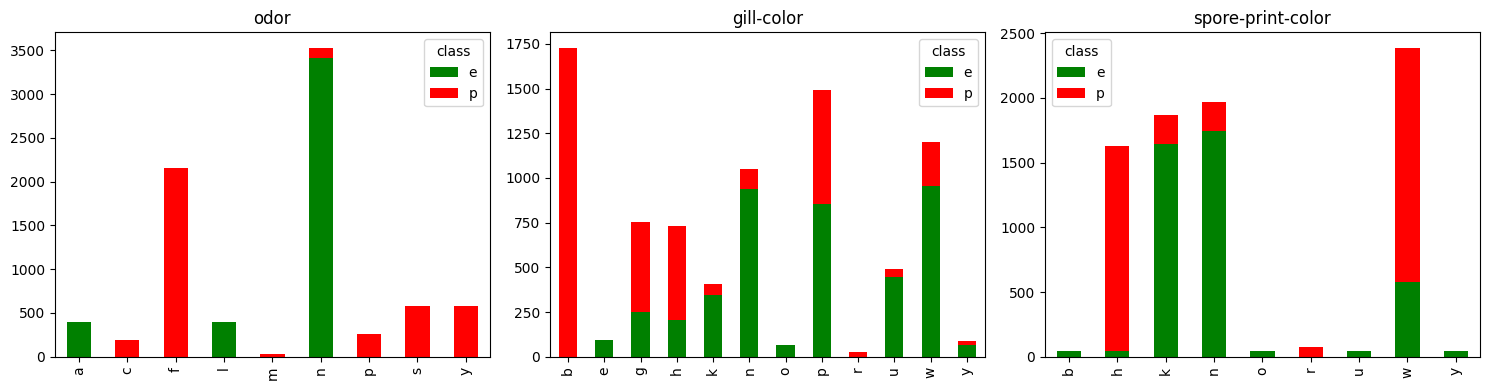

In [8]:
# cek distribusi beberapa fitur yg kayaknya penting
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, feat in enumerate(['odor', 'gill-color', 'spore-print-color']):
    ct = pd.crosstab(df[feat], df['class'])
    ct.plot(kind='bar', stacked=True, ax=axes[idx], color=['green','red'])
    axes[idx].set_title(feat)
    axes[idx].set_xlabel('')

plt.tight_layout()
plt.show()

In [9]:
# odor kelihatannya paling diskriminatif, cek lebih detail
pd.crosstab(df['odor'], df['class'], normalize='index').round(3)

class,e,p
odor,,
a,1.000,0.000
c,0.000,1.000
f,0.000,1.000
l,1.000,0.000
m,0.000,1.000
n,0.966,0.034
p,0.000,1.000
s,0.000,1.000
y,0.000,1.000


# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [10]:
# handle missing value '?' di stalk-root
# jumlahnya lumayan banyak (~30%) jadi sayang kalo di-drop, mending biarin jadi kategori sendiri aja
print(f"Jumlah '?': {(df['stalk-root'] == '?').sum()} dari {len(df)} baris")
print("Keputusan: biarkan '?' sebagai kategori tersendiri")

Jumlah '?': 2480 dari 8124 baris
Keputusan: biarkan '?' sebagai kategori tersendiri


In [11]:
# cek fitur yang cuma punya 1 value (ga berguna)
cols_to_drop = [col for col in df.columns if df[col].nunique() == 1]
print('Kolom yang di-drop:', cols_to_drop)
df = df.drop(columns=cols_to_drop)
print('Shape setelah drop:', df.shape)

Kolom yang di-drop: ['veil-type']
Shape setelah drop: (8124, 22)


In [12]:
# pisahkan X dan y, encode target
X = df.drop(columns=['class'])
y = df['class'].map({'e': 0, 'p': 1})

# split data 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Train: 6499, Test: 1625


In [13]:
# encoding untuk CategoricalNB -> OrdinalEncoder
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_ord = ord_enc.fit_transform(X_train)
X_test_ord = ord_enc.transform(X_test)
print('Shape ordinal:', X_train_ord.shape)

Shape ordinal: (6499, 21)


In [14]:
# encoding untuk BernoulliNB & MultinomialNB -> OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_train_ohe = ohe.fit_transform(X_train)
X_test_ohe = ohe.transform(X_test)
print('Shape one-hot:', X_train_ohe.shape)

Shape one-hot: (6499, 116)


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [15]:
cat_nb = CategoricalNB()
cat_nb.fit(X_train_ord, y_train)

y_pred_cat = cat_nb.predict(X_test_ord)
y_prob_cat = cat_nb.predict_proba(X_test_ord)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred_cat))

Accuracy: 0.9458461538461539


## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [16]:
ber_nb = BernoulliNB()
ber_nb.fit(X_train_ohe, y_train)

y_pred_ber = ber_nb.predict(X_test_ohe)
y_prob_ber = ber_nb.predict_proba(X_test_ohe)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred_ber))

Accuracy: 0.932923076923077


## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [17]:
mul_nb = MultinomialNB()
mul_nb.fit(X_train_ohe, y_train)

y_pred_mul = mul_nb.predict(X_test_ohe)
y_prob_mul = mul_nb.predict_proba(X_test_ohe)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred_mul))

Accuracy: 0.9458461538461539


# 4. Evaluasi Model

In [18]:
# bikin tabel perbandingan
nama_model = ['CategoricalNB', 'BernoulliNB', 'MultinomialNB']
prediksi = [y_pred_cat, y_pred_ber, y_pred_mul]
probabilitas = [y_prob_cat, y_prob_ber, y_prob_mul]

rows = []
for name, pred, prob in zip(nama_model, prediksi, probabilitas):
    rows.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall': round(recall_score(y_test, pred), 4),
        'F1-Score': round(f1_score(y_test, pred), 4),
        'AUC': round(roc_auc_score(y_test, prob), 4)
    })

hasil = pd.DataFrame(rows)
hasil

,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,CategoricalNB,0.9458,0.9901,0.8966,0.9410,0.9972
1,BernoulliNB,0.9329,0.9814,0.8774,0.9265,0.9954
2,MultinomialNB,0.9458,0.9901,0.8966,0.9410,0.9972


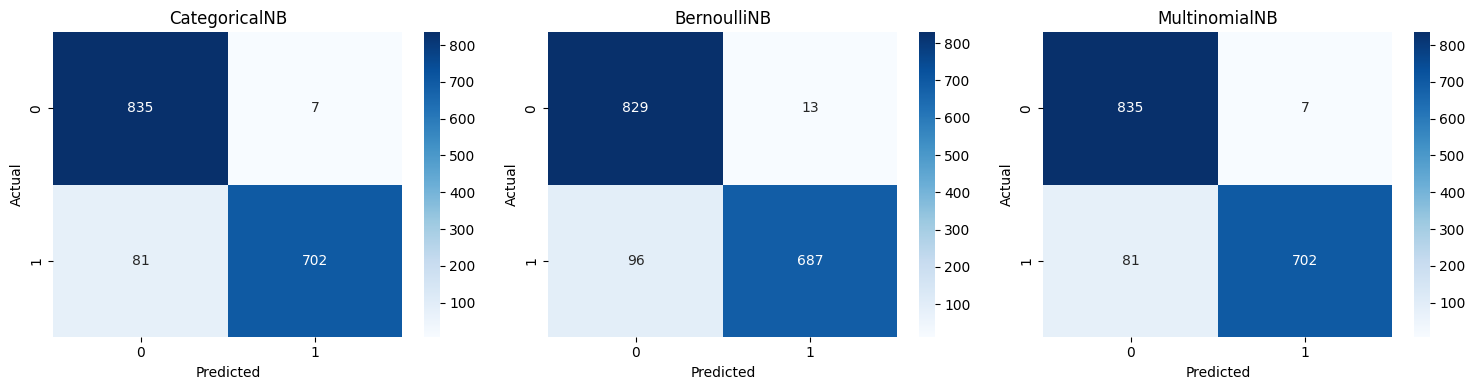

In [19]:
# confusion matrix
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, pred) in enumerate(zip(nama_model, prediksi)):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

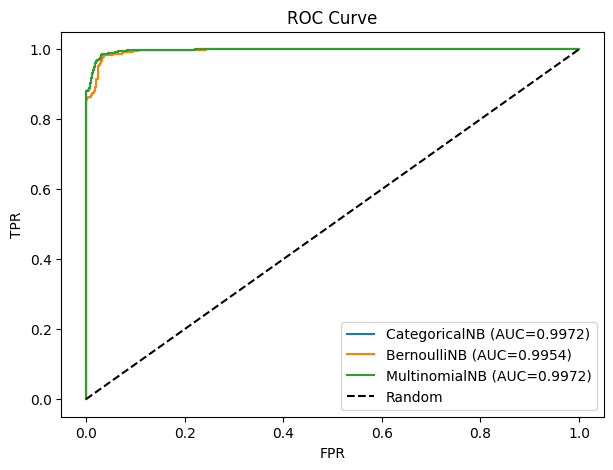

In [20]:
# ROC curve
plt.figure(figsize=(7, 5))

for name, prob in zip(nama_model, probabilitas):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 5. Analisis

Dari hasil eksperimen di atas, bisa dilihat bahwa ketiga model Naive Bayes punya performa yang cukup tinggi (accuracy >93%), tapi ada perbedaan yang menarik.

CategoricalNB dan MultinomialNB ternyata hasilnya sama persis, sementara BernoulliNB sedikit lebih rendah. Menurut saya ini karena CategoricalNB memang dirancang khusus untuk data kategorikal, jadi dia bisa langsung menghitung probabilitas per kategori tanpa perlu ubah representasi datanya. Sedangkan BernoulliNB harus pakai one-hot encoding dulu yang bikin fitur-fitur dari kolom yang sama jadi terpisah, padahal sebenernya mereka saling eksklusif (misal cap-shape cuma bisa satu nilai). Ini bisa melanggar asumsi independensi dari NB.

Untuk MultinomialNB, walaupun secara teori dia lebih cocok untuk data frekuensi (kayak text classification), ternyata di dataset ini hasilnya sama bagusnya dengan CategoricalNB. Kemungkinan karena distribusi datanya yang memang cukup clean dan fitur-fitur kategorialnya cukup informatif.

Kalau dilihat dari AUC-nya, ketiga model juga sangat tinggi (>0.99), ini menandakan bahwa dataset mushroom ini sebenernya relatif "mudah" untuk diklasifikasi. Beberapa fitur seperti `odor` sudah sangat diskriminatif dari EDA yang tadi dilakukan.

# 6. Kesimpulan dan Saran

**Kesimpulan:**

CategoricalNB jadi pilihan paling tepat untuk dataset ini karena memang didesain untuk fitur kategorikal. Tapi secara keseluruhan, ketiga model NB performanya bagus semua karena dataset mushroom ini punya fitur-fitur yang sangat informatif.

Perbedaan utama antar model terletak di cara mereka merepresentasikan data. CategoricalNB pakai ordinal encoding dan langsung treat sebagai kategori, sementara BernoulliNB dan MultinomialNB butuh one-hot encoding yang mengubah 1 kolom jadi banyak kolom binary.

**Saran:**

- Bisa dicoba tuning parameter `alpha` (smoothing) untuk lihat pengaruhnya ke performa
- Menarik juga kalau dibandingkan dengan model lain seperti Decision Tree atau Random Forest
- Bisa juga coba feature selection untuk lihat apakah dengan fitur yang lebih sedikit hasilnya tetap bagus